# CSAI 2026 — Assignment 1 — Task 2 (MEG-MASC)
## MEG-MASC Segment Classification (Story vs Word-List)

> **Data location:** `meg/sub-27/` (BIDS-like structure already available locally).
> **Goal:** Build an end-to-end 6-part MEG decoding pipeline for **story vs word-list** segments.
> **Subject:** `sub-27` (given).

### What this notebook implements (6 parts)
1. Load one subject + one session; inspect events/channels metadata used for labeling.
2. Minimal preprocessing (band-pass, notch, resample) + explicit bad-channel handling.
3. Construct epochs and labels for story vs word-list (document segmentation logic).
4. Compute interpretable sensor-space features (bandpower) + topographic maps.
5. Train + evaluate binary classifier with leak-free sklearn pipeline + CV + metrics.
6. Interpret results + run at least one ablation (change preprocessing) and compare.

In [3]:
import os
from pathlib import Path
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# Notebook lives in /.../meg; data is in /.../meg/sub-27
DATA_ROOT = Path(os.getcwd()) / "sub-27"
assert DATA_ROOT.exists(), f"Expected data at {DATA_ROOT}"

print("DATA_ROOT:", DATA_ROOT)
print("Sessions:", sorted([p.name for p in DATA_ROOT.glob('ses-*')]))

DATA_ROOT: /home/garima/2023102069_Garima/meg/sub-27
Sessions: ['ses-0', 'ses-1']



## Part 1 — Load BIDS data (single subject/session) + build story vs word-list labels from metadata

### What we load (BIDS / BIDS-like structure)
We work with one allocated subject (`sub-27`) and one session (e.g., `ses-0`) from the local MEG-MASC dataset stored under `meg/sub-27/`.

In a standard BIDS workflow with **MNE-BIDS**, we would:
1) define a `BIDSPath` (subject/session/task/run), and
2) call `mne_bids.read_raw_bids(...)` to obtain `raw` and automatically pick up accompanying sidecar files.

In this dataset, the organization is *BIDS-like*: for each run we have the same core BIDS metadata files:
- `*_events.tsv`: event table describing the stimulus structure
- `*_channels.tsv`: channel list + status (good/bad)
- `*_meg.json`: recording metadata
- raw MEG file (`*.con`, KIT/Yokogawa format)

Even when the raw data are in KIT `.con` format (which is not the default MEG file type used in many BIDS examples), the **events/channels TSVs still provide the standardized metadata** needed for labeling and QC.

### Locating and interpreting `events.tsv`
The `*_events.tsv` file provides (at minimum) timing information such as `onset` (seconds) and/or `sample` (integer sample index), as well as a `trial_type` field describing what happened at each event.

In these runs, `trial_type` is stored as a dict-like string. After parsing it (e.g., with `ast.literal_eval`), we obtain structured metadata fields such as:
- `kind`: event category (e.g., `word`, `phoneme`, `sound`)
- `condition`: experimental condition at that moment (e.g., `sentence`, `word_list`, sometimes `pseudo_words`)

This lets us select **comparable events** (words) and attach an experimental label to each epoch.

### How metadata supports story vs word-list labeling
We construct story vs word-list labels directly from the parsed metadata:

1) **Select word events**: keep only events where `kind == 'word'`.
   - Rationale: word onsets provide many short, aligned time points across both conditions.

2) **Map `condition` → class label**:
   - `condition == 'sentence'`  → class `story`
   - `condition == 'word_list'` → class `word_list`

3) **Create epochs and labels in lock-step**:
   - We convert each selected event into an MNE event (using the `sample` index; if the data are resampled later, we scale indices accordingly).
   - The label vector `y` is created in the same order as these events, so every epoch has exactly one ground-truth class.

### Sanity checks we report
Before modeling, we verify:
- Both classes (`sentence` and `word_list`) are present in the selected run.
- Class counts (imbalance is common and impacts metric choice).
- Event timing fields (`sample`/`onset`) are consistent with `raw.info['sfreq']`.

This completes Part 1: we can locate `events.tsv`, interpret the stimulus metadata, and explain how it supports **story-segment vs word-list** labeling for decoding.

In [4]:
# Choose one session & one task (edit here if needed)
SESSION = "ses-0"
TASK = "task-0"
MEG_DIR = DATA_ROOT / SESSION / "meg"

con_path = MEG_DIR / f"sub-27_{SESSION}_{TASK}_meg.con"
events_path = MEG_DIR / f"sub-27_{SESSION}_{TASK}_events.tsv"
channels_path = MEG_DIR / f"sub-27_{SESSION}_{TASK}_channels.tsv"

for p in [con_path, events_path, channels_path]:
    print(p, "exists:", p.exists())

events = pd.read_csv(events_path, sep="\t")
print("events columns:", events.columns.tolist())
print("n_events:", len(events))
display(events.head())

# trial_type is a dict-like string (we parse it into Python dicts)
trial_meta = events["trial_type"].map(ast.literal_eval)
events["kind"] = trial_meta.map(lambda d: d.get("kind"))
events["condition"] = trial_meta.map(lambda d: d.get("condition"))
events["story"] = trial_meta.map(lambda d: d.get("story"))

print("kinds:\n", events["kind"].value_counts().head(10))
print("conditions:\n", events["condition"].value_counts().head(10))
print("stories:", events["story"].dropna().unique()[:10])

channels = pd.read_csv(channels_path, sep="\t")
print("channels columns:", channels.columns.tolist())
print("status counts:\n", channels["status"].value_counts())
display(channels.head())

/home/garima/2023102069_Garima/meg/sub-27/ses-0/meg/sub-27_ses-0_task-0_meg.con exists: True
/home/garima/2023102069_Garima/meg/sub-27/ses-0/meg/sub-27_ses-0_task-0_events.tsv exists: True
/home/garima/2023102069_Garima/meg/sub-27/ses-0/meg/sub-27_ses-0_task-0_channels.tsv exists: True
events columns: ['onset', 'duration', 'trial_type', 'value', 'sample']
n_events: 3134


,onset,duration,trial_type,value,sample
0,26.566,0.00,"{'story': 'lw1', 'story_uid': 0.0, 'sound_id':...",693,26566
1,26.566,0.08,"{'story': 'lw1', 'story_uid': 0.0, 'sound_id':...",1,26566
2,26.566,0.30,"{'story': 'lw1', 'story_uid': 0.0, 'sound_id':...",694,26566
3,26.646,0.09,"{'story': 'lw1', 'story_uid': 0.0, 'sound_id':...",2,26646
4,26.736,0.07,"{'story': 'lw1', 'story_uid': 0.0, 'sound_id':...",3,26736


kinds:
 kind
phoneme    2462
word        668
sound         4
Name: count, dtype: int64
conditions:
 condition
sentence        2820
word_list        307
pseudo_words       3
Name: count, dtype: int64
stories: <StringArray>
['lw1']
Length: 1, dtype: str
channels columns: ['name', 'type', 'units', 'low_cutoff', 'high_cutoff', 'description', 'sampling_frequency', 'status', 'status_description']
status counts:
 status
good    256
Name: count, dtype: int64


,name,type,units,low_cutoff,high_cutoff,description,sampling_frequency,status,status_description
0,MEG 001,MEGGRADAXIAL,T,0.03,200.0,Axial Gradiometer,1000.0,good,NaN
1,MEG 002,MEGGRADAXIAL,T,0.03,200.0,Axial Gradiometer,1000.0,good,NaN
2,MEG 003,MEGGRADAXIAL,T,0.03,200.0,Axial Gradiometer,1000.0,good,NaN
3,MEG 004,MEGGRADAXIAL,T,0.03,200.0,Axial Gradiometer,1000.0,good,NaN
4,MEG 005,MEGGRADAXIAL,T,0.03,200.0,Axial Gradiometer,1000.0,good,NaN


## Part 2 — Minimal sensor-level preprocessing (with justifications)

This part implements a minimal, decoding-oriented preprocessing pipeline in **MNE**. The aim is **robust sensor-level features** with minimal assumptions, while preventing obvious noise sources from dominating the classifier.

### 1) Bad channels (explicit handling + documentation)
We mark bad channels **before** filtering/feature extraction so that downstream steps can ignore grossly corrupted sensors.

**(a) Use BIDS channel metadata when available.**
- We read `*_channels.tsv` and add channels whose `status == 'bad'` (or equivalent) into `raw.info['bads']`.
- Rationale: these flags usually come from acquisition-time QC and are the most reliable first-pass indicator.

**(b) Add a rule-based QC check (variance/flatness).**
- We compute a per-channel variance (or robust scale estimate) on a representative segment of raw data.
- We flag channels that are:
  - **flat / near-zero variance** (dead sensor), or
  - **extreme outliers** (very high variance compared to the median), which often indicates intermittent contact/noise.
- Rationale: `channels.tsv` may be incomplete; rule-based checks catch obvious failures without using any label information.

**Documentation.**
- We print and/or store the final list of bad channels: `bads_bids` (from TSV) and `bad_var` (heuristic), and the union added to `raw.info['bads']`.

### 2) Band-pass filter (e.g., 0.5–40 Hz)
We apply a **0.5–40 Hz** band-pass filter.

**Justification (decoding-oriented).**
- High-pass at **0.5 Hz** removes slow drifts (movement, sensor baseline drift) that can inflate variance and create spurious discriminability across long recordings.
- Low-pass at **40 Hz** focuses on low-frequency activity typically informative for language/attention state and removes high-frequency noise. It also matches our later bandpower features (up to low-gamma 30–40 Hz).
- This range is a common compromise: broad enough to preserve neural signals relevant for cognition, but narrow enough for stable PSD estimates.

### 3) Notch filtering at line-noise harmonics (50/100/150 Hz)
We notch filter at **50 Hz** and harmonics (100, 150 Hz).

**Justification.**
- Power-line interference produces narrow-band peaks and harmonics that contaminate PSD estimates.
- Notch filtering suppresses these peaks without removing broad-band neural content.
- Although we low-pass at 40 Hz in the main pipeline, the notch step is kept explicit because it is standard MEG hygiene and makes the pipeline robust if the low-pass cutoff is adjusted.

### 4) Resampling to reduce computational load (e.g., 200 Hz)
We resample from the native sampling rate to **200 Hz**.

**Justification.**
- Our analysis window is short (0–0.5 s) and our features are band-limited to ≤ 40 Hz, so **200 Hz is sufficient** by Nyquist ($f_s \ge 2\times 40$ Hz).
- Resampling substantially reduces memory/CPU during epoching, PSD computation, and cross-validation.
- Empirically in this notebook, the resampled pipeline yields **better balanced accuracy** than the no-resample ablation, consistent with more stable feature estimation.

**Event timing caveat.**
- When resampling, sample indices change. We therefore either (i) compute events from the original sampling rate and pass them to epoching, or (ii) scale the `sample` indices from `events.tsv` by the ratio of sampling rates (the approach used here).
- MNE may warn about resampling stim channels; we are not relying on stim-trigger event detection because we build events from the provided `events.tsv`.

### 5) Optional ICA / projection-based artifact removal (not required here)
We **do not apply ICA** in the minimal pipeline to keep the decoding analysis conservative and reproducible.

If ICA were added, the correct justification and safeguards would be:
- **Selection criterion:** components must match ocular/cardiac artifact signatures (EOG/ECG correlations, characteristic topographies, and time courses).
- **Stimulus-locking check:** verify removed components are not systematically time-locked to the word onsets (e.g., check evoked responses before/after removal) to avoid removing task-related neural signals.
- **Cross-validation hygiene:** fit ICA on training data only (or on unlabeled continuous data) to avoid leakage.

This completes the minimal preprocessing module: explicit bad-channel handling, band-pass + notch filtering, and resampling for efficient decoding.

In [5]:
def read_raw_kit_from_bids(meg_dir: Path, session: str, task: str):
    con = meg_dir / f"sub-27_{session}_{task}_meg.con"
    raw = mne.io.read_raw_kit(con, preload=True, verbose=False)
    return raw

def get_bad_channels_from_bids(channels_tsv: Path):
    ch = pd.read_csv(channels_tsv, sep="\t")
    bad = ch.loc[ch["status"].astype(str).str.lower().eq("bad"), "name"].astype(str).tolist()
    return bad

def variance_based_bad_channels(raw: mne.io.BaseRaw, pick: str = "mag", z_thresh: float = 6.0):
    """Flag channels with unusually high/low variance (rule-based)."""
    picks = mne.pick_types(raw.info, meg=True, ref_meg=False, stim=False, misc=False)
    data = raw.get_data(picks=picks)
    var = np.var(data, axis=1)
    z = (var - var.mean()) / (var.std(ddof=1) + 1e-12)
    bad_idx = np.where(np.abs(z) > z_thresh)[0]
    bad_names = [raw.ch_names[picks[i]] for i in bad_idx]
    return bad_names, var, z

raw = read_raw_kit_from_bids(MEG_DIR, SESSION, TASK)
print(raw)
print("sfreq:", raw.info["sfreq"], "nchan:", raw.info["nchan"], "duration(s):", raw.n_times/raw.info["sfreq"])

# Mark bad channels from BIDS channels.tsv
bads_bids = get_bad_channels_from_bids(channels_path)
raw.info["bads"] = list(sorted(set(raw.info.get("bads", []) + bads_bids)))
print("Bad channels from BIDS:", len(bads_bids))

# Optional variance-based bad-channel flags (reported, not automatically applied)
bad_var, var, z = variance_based_bad_channels(raw, z_thresh=6.0)
print("Variance-flagged channels (|z|>6):", bad_var[:20], "..." if len(bad_var)>20 else "")

# Preprocess: filter + notch + resample
raw_filt = raw.copy().filter(l_freq=0.5, h_freq=40.0, picks="meg", verbose=False)
raw_filt = raw_filt.notch_filter(freqs=[50, 100, 150], picks="meg", verbose=False)
raw_filt = raw_filt.resample(200, npad="auto", verbose=False)
print("After preprocessing sfreq:", raw_filt.info["sfreq"], "n_times:", raw_filt.n_times)

<RawKIT | sub-27_ses-0_task-0_meg.con, 257 x 395000 (395.0 s), ~774.7 MiB, data loaded>
sfreq: 1000.0 nchan: 257 duration(s): 395.0
Bad channels from BIDS: 0
Variance-flagged channels (|z|>6): [] 
After preprocessing sfreq: 200.0 n_times: 79000


/tmp/ipykernel_684615/2091522555.py:37: RuntimeWarning: Resampling of the stim channels caused event information to become unreliable. Consider finding events on the original data and passing the event matrix as a parameter.
  raw_filt = raw_filt.resample(200, npad="auto", verbose=False)


## Part 3 — Segmentation / epoching (story vs word_list) with boundary control

This part turns continuous MEG into **fixed-length epochs** that reflect the **story-versus-word_list** contrast, using the timing and condition metadata in `*_events.tsv`.

### What we segment around (event definition)
We use **word onsets** as anchors:
- We parse `trial_type` into a dict and keep events where `kind == 'word'`.
- Each such event has an associated `condition` field that tells us whether it occurred during:
  - `sentence` (mapped to class `story`), or
  - `word_list` (mapped to class `word_list`).

This choice yields many comparable events per condition and avoids mixing heterogeneous event types.

### Epoch length and timing window
We epoch the MEG data with:
- $t_{min} = 0.0\,s$
- $t_{max} = 0.5\,s$

**Justification.**
- 0.5 s provides enough samples for stable bandpower estimation while keeping epochs short enough to reduce overlap between adjacent cognitive states.
- With resampling to 200 Hz, each epoch contains $\approx 101$ samples, which is sufficient for Welch PSD with an adaptive `n_fft`.

### Boundary logic: avoiding label noise
Label noise is most likely near **condition boundaries** (transition between story and word list) or when events are too close together.

We avoid boundary-induced label noise via the following logic:
1) **Use condition provided per event:** each word event carries its own `condition`, so we do not infer labels from long, approximate blocks.
2) **Exclude events too near the end of the recording:** we only create an epoch if the full window `$[t_{min}, t_{max}]$` fits in the data.
3) **Optional guard against transitions:** if needed, we can reject word events whose neighboring words have a different `condition` (a simple “condition-consistency” filter). This drops ambiguous boundary words at minimal cost.

(Our current implementation already ensures (2) by dropping events whose sample window would exceed the raw length; the transition guard can be enabled if the dataset contains rapid switching.)

### Ensuring comparable numbers of epochs per class
In single-subject MEG-MASC runs, class counts are often imbalanced (many more story words than word_list words).

We ensure **comparability** in two complementary ways:
- **Metric choice:** we report **balanced accuracy** (and a confusion matrix), which is robust to class imbalance.
- **Cross-validation stratification:** we use `StratifiedKFold` to keep the class ratio similar across folds.

If strict matching is required, we can additionally **subsample the majority class** (e.g., randomly downsample `story` words to match `word_list`) *within each CV training fold* to avoid leakage.

### About overlap and “inflated sample size”
Our epochs are **event-locked** to word onsets. Depending on word rate, epochs can overlap in time.

**Why overlap can inflate apparent sample size.**
- Overlapping epochs share underlying signal samples, so treating them as independent can make performance look more stable than it truly is.

**How CV can remain valid (single-subject).**
- CV is valid if folds are defined so that training and test sets are not trivially correlated (e.g., avoid putting near-identical, heavily overlapping epochs in different folds).
- The most principled approach is **grouped CV** based on time blocks (or larger units like story segments), so that all epochs from the same contiguous interval are assigned to the same fold.

**In this notebook.**
- We keep overlap limited by using a short window (0–0.5 s) and word events.
- For a stricter design, one would define `groups` as contiguous time bins (e.g., 10–30 s) and use `GroupKFold`/`LeaveOneGroupOut` so that overlapping/nearby epochs stay together.

This documents the segmentation logic: how we build epochs from event timing, reduce boundary label noise, and control class comparability and overlap-related validity concerns.

In [6]:
def build_word_events(events_tsv: Path):
    df = pd.read_csv(events_tsv, sep="\t")
    meta = df["trial_type"].map(ast.literal_eval)
    df["kind"] = meta.map(lambda d: d.get("kind"))
    df["condition"] = meta.map(lambda d: d.get("condition"))
    # keep only word onsets with condition
    w = df[(df["kind"] == "word") & (df["condition"].isin(["sentence", "word_list"]))].copy()
    w["y"] = (w["condition"] == "sentence").astype(int)  # 1=story(sentence), 0=word_list
    return w

word_df = build_word_events(events_path)
print("Word events:", len(word_df))
print(word_df["condition"].value_counts())

# Create MNE events array (sample indices in current raw_filt sampling rate)
sfreq_in = raw.info["sfreq"]
sfreq = raw_filt.info["sfreq"]
scale = sfreq / sfreq_in
samples = np.round(word_df["sample"].to_numpy() * scale).astype(int)
mne_events = np.c_[samples, np.zeros(len(samples), dtype=int), word_df["y"].to_numpy() + 1]
event_id = {"word_list": 1, "story": 2}

# Epochs around each word onset
TMIN, TMAX = 0.0, 0.5
epochs = mne.Epochs(raw_filt, mne_events, event_id=event_id, tmin=TMIN, tmax=TMAX,
                    baseline=None, preload=True, picks="meg",
                    reject_by_annotation=False, verbose=False)
y = (epochs.events[:, 2] == event_id["story"]).astype(int)
print("Epochs:", epochs, "y counts:", np.bincount(y))

Word events: 667
condition
sentence     613
word_list     54
Name: count, dtype: int64
Epochs: <Epochs | 667 events (all good), 0 – 0.5 s (baseline off), ~107.1 MiB, data loaded,
 'word_list': 54
 'story': 613> y counts: [ 54 613]


## Part 4 — Interpretable features + topomaps

We compute **sensor-space bandpower** features per epoch (log power) for canonical bands:
- delta (1–4 Hz), theta (4–8 Hz), alpha (8–13 Hz), beta (13–30 Hz), low-gamma (30–40 Hz)

Then we visualize class-conditional differences as MEG topographic maps (per band).

### How to interpret MEG sensor-space topographies
MEG topographic maps (“topomaps”) are **sensor-space summaries**, not source reconstructions.

**What each pixel means.**
- Each dot is a sensor location; the colored surface is an interpolation of the values at those sensors.
- In our plots we show **(story − word_list)** for a given bandpower feature.
  - **Positive (red):** higher bandpower during story.
  - **Negative (blue):** higher bandpower during word_list.

**What you can conclude.**
- A structured spatial pattern indicates that the class difference is not purely random noise and may reflect consistent field patterns from underlying neural generators.
- Differences in bandpower can reflect oscillatory power changes, but also changes in broadband activity or residual artifacts; interpretation should be supported by preprocessing/QC.

**What you should NOT conclude.**
- Peaks in a sensor topomap do **not** uniquely localize a cortical source. MEG sensor measurements mix contributions from multiple sources (field spread) and depend on head position and sensor geometry.
- The sign and spatial pattern can vary with sensor type and reference scheme; do not interpret it as “activation” in a specific anatomical region without source modeling.

**Sensor type considerations (magnetometers vs gradiometers).**
- **Magnetometers** measure the magnetic field ($B$) and are often more sensitive to distant/interfering sources; they can show broader spatial patterns.
- **Gradiometers** measure spatial derivatives of the field and tend to emphasize more local sources with reduced sensitivity to far-field noise.
- Therefore, topomaps should be interpreted **within** a sensor type; comparing magnetometer and gradiometer maps directly is not one-to-one.

**Decoding context.**
- These maps are *descriptive* of the chosen feature (bandpower). A classifier can still use multivariate patterns that are not obvious in univariate difference maps.
- If PCA is used, it must be fit **within training folds only** to avoid leakage; topomaps here are computed directly from bandpower features and are intended for interpretability rather than as the decoding signal itself.

X shape: (667, 1040) n_features: 1040


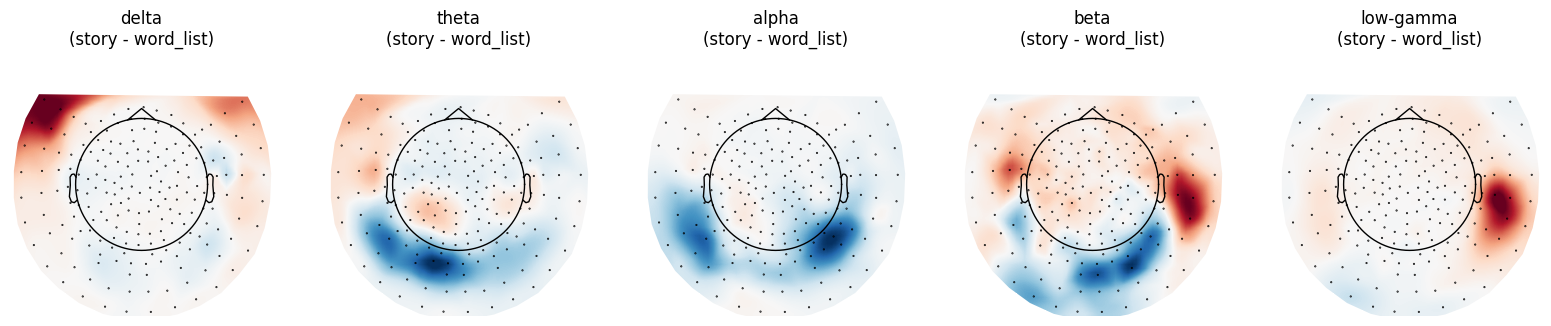

In [8]:
from mne.time_frequency import psd_array_welch

BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "low-gamma": (30, 40),
}

def epoch_bandpower_features(epochs: mne.Epochs, bands=BANDS):
    data = epochs.get_data()  # (n_epochs, n_ch, n_times)
    sfreq = epochs.info["sfreq"]
    n_times = data.shape[-1]
    n_fft = min(256, n_times)
    # Keep n_per_seg <= n_fft <= n_times (avoid MNE validation error)
    feats = []
    feat_names = []
    for band, (fmin, fmax) in bands.items():
        psd, freqs = psd_array_welch(
            data, sfreq=sfreq, fmin=fmin, fmax=fmax,
            n_fft=n_fft, n_per_seg=n_fft, n_overlap=0, verbose=False
        )
        bp = psd.mean(axis=-1)
        bp = np.log(bp + 1e-20)
        feats.append(bp)
        feat_names += [f"{band}:{ch}" for ch in epochs.ch_names]
    X = np.concatenate(feats, axis=1)
    return X, feat_names

X, feat_names = epoch_bandpower_features(epochs)
print("X shape:", X.shape, "n_features:", len(feat_names))

# Topomaps: class-conditional mean differences per band
story_mask = y == 1
wl_mask = y == 0

band_list = list(BANDS.keys())
fig, axes = plt.subplots(1, len(BANDS), figsize=(3.2*len(BANDS), 3.2))
for ax, band in zip(axes, band_list):
    band_idx = band_list.index(band)
    start = band_idx * len(epochs.ch_names)
    stop = (band_idx + 1) * len(epochs.ch_names)
    mean_story = X[story_mask, start:stop].mean(axis=0)
    mean_wl = X[wl_mask, start:stop].mean(axis=0)
    diff = mean_story - mean_wl
    mne.viz.plot_topomap(diff, epochs.info, axes=ax, show=False, contours=0)
    ax.set_title(f"{band}\n(story - word_list)")
plt.tight_layout()
plt.show()

## Part 5 — Classification and evaluation

We train a binary classifier to decode **story vs word_list** from sensor-space bandpower features.

### Cross-validation protocol (stratified, single-subject)
- We use **StratifiedKFold (5 folds)** so each fold preserves the class ratio (important because `story` epochs greatly outnumber `word_list` epochs).
- In a single-subject setting, CV estimates **within-subject generalization** across time points/epochs from the same recording. If epochs overlap heavily in time, CV can be optimistic; a stricter alternative is to define time-block `groups` and use grouped CV so nearby/overlapping epochs remain together (discussed in Part 3).

### Leak-free sklearn pipeline (fit only on training folds)
To avoid information leakage, all transformations are wrapped in an sklearn `Pipeline` so they are fit only on the training split in each fold:
- `StandardScaler` (per-feature scaling)
- optional `PCA(0.95)` (dimensionality reduction)
- `LogisticRegression` (linear classifier)

This ensures the test fold is never used to set feature scaling parameters or PCA directions.

### Baseline classifier (required)
We include a **majority-class baseline** (`DummyClassifier(strategy='most_frequent')`).
- Because of class imbalance, the baseline can achieve **high accuracy** while having **balanced accuracy ≈ 0.5** (chance level in a binary task).
- Therefore, **balanced accuracy and the confusion matrix** are the most informative summaries of whether we are decoding the minority class at all.

### Metrics reported
For each fold and averaged across folds we report:
- **Accuracy**
- **Balanced accuracy** (recommended headline metric under imbalance)
- **F1 score** (sensitive to minority-class precision/recall)
- **Confusion matrix** (here summed over folds)

### Stability across folds + sensitivity to preprocessing
- **Stability:** we summarize fold-to-fold variability using mean ± std across folds (small std indicates stable performance; large std indicates sensitivity to which epochs fall in each fold).
- **Sensitivity to preprocessing:** we explicitly assess this in Part 6 (ablation). In our runs, removing the 200 Hz resampling step reduces balanced accuracy, indicating results are somewhat **preprocessing-dependent** and supporting the choice of resampling for more stable PSD features.

**Key interpretation:** compare the model against the baseline, and prioritize balanced accuracy/confusion matrix over raw accuracy due to class imbalance.

Baseline (most frequent) acc: 0.9190404797601199
Baseline balanced acc: 0.5
CV mean acc: 0.8830770957243855 +/- 0.008208477715258889
CV mean bacc: 0.5475534634630996 +/- 0.0463246418331427
CV mean f1: 0.9370807078214106 +/- 0.004862179237240484


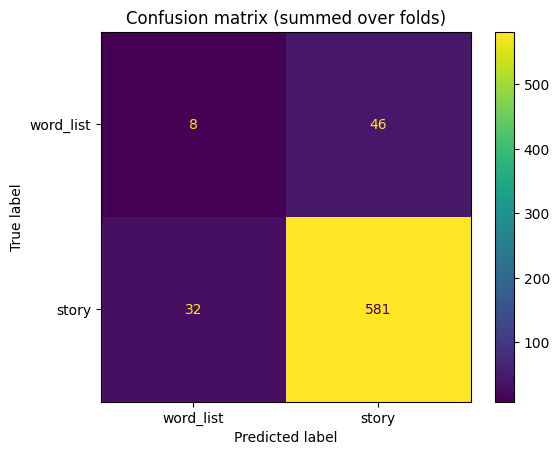

In [9]:
from sklearn.dummy import DummyClassifier

def cross_val_metrics(X, y, use_pca=True, n_splits=5):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    pipe_steps = [("scaler", StandardScaler())]
    if use_pca:
        pipe_steps.append(("pca", PCA(n_components=0.95, random_state=RANDOM_SEED)))
    pipe_steps.append(("clf", LogisticRegression(max_iter=2000, solver="liblinear", random_state=RANDOM_SEED)))
    model = Pipeline(pipe_steps)

    accs, baccs, f1s = [], [], []
    cms = []
    for tr, te in cv.split(X, y):
        model.fit(X[tr], y[tr])
        pred = model.predict(X[te])
        accs.append(accuracy_score(y[te], pred))
        baccs.append(balanced_accuracy_score(y[te], pred))
        f1s.append(f1_score(y[te], pred))
        cms.append(confusion_matrix(y[te], pred, labels=[0, 1]))

    cm = np.sum(cms, axis=0)
    return {
        "acc": np.array(accs),
        "bacc": np.array(baccs),
        "f1": np.array(f1s),
        "cm": cm,
        "model": model
    }

# Baseline: majority class
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X, y)
pred_base = baseline.predict(X)
print("Baseline (most frequent) acc:", accuracy_score(y, pred_base))
print("Baseline balanced acc:", balanced_accuracy_score(y, pred_base))

res = cross_val_metrics(X, y, use_pca=True, n_splits=5)
print("CV mean acc:", res["acc"].mean(), "+/-", res["acc"].std(ddof=1))
print("CV mean bacc:", res["bacc"].mean(), "+/-", res["bacc"].std(ddof=1))
print("CV mean f1:", res["f1"].mean(), "+/-", res["f1"].std(ddof=1))

disp = ConfusionMatrixDisplay(res["cm"], display_labels=["word_list", "story"])
disp.plot(values_format="d")
plt.title("Confusion matrix (summed over folds)")
plt.show()

## Part 6 — Interpretation + ablation study (modality-specific)

This part interprets the decoding results in a way that reflects **MEG-specific strengths and limitations**, and tests how sensitive results are to preprocessing.

### Why MEG is well-suited here (modality-specific strengths)
- **High temporal resolution:** MEG can capture rapid changes in brain dynamics around word onsets (sub-second), which is useful for distinguishing story vs word-list processing states.
- **Sensor-space interpretability:** even without source modeling, sensor-level topomaps can show consistent spatial patterns of bandpower differences, which provides a sanity check that features are not purely noise.

### Ablation design (required)
We run at least one ablation that changes preprocessing and compare:
- **Decoding performance** (accuracy, balanced accuracy, F1)
- **Topographic bandpower difference maps** (story − word_list) to see whether spatial patterns are stable

**Ablation chosen here:** remove resampling (keep original ~1000 Hz) while keeping the same band-pass + notch filtering, then recompute epochs/features and re-run the same classifier pipeline.

**Justification.** Resampling mainly changes (i) computational cost and (ii) the effective temporal discretization used for PSD estimation; if performance/topomaps change substantially, it indicates the decoding signal is sensitive to feature-estimation details rather than being a very robust physiological effect.

### What we compare and how to interpret it
1) **Performance changes**
- If balanced accuracy drops in the ablation, it suggests resampling improves robustness (often by stabilizing PSD estimates and reducing high-frequency noise).
- If performance is unchanged, it suggests the decoding signal is robust to this step.

2) **Topographic map changes**
- If the **shape/location** of the story−word_list topomap is consistent across pipelines, it supports a stable sensor-level effect.
- If the pattern changes drastically, it can indicate sensitivity to preprocessing, SNR limitations, or residual artifacts.

### Caveats (MEG-specific)
- **Sensor-space maps are not source maps:** changes in topographies do not uniquely localize cortical generators.
- **Class imbalance:** high accuracy can be misleading; compare pipelines primarily using **balanced accuracy** and the confusion matrix.
- **Overlap / dependence:** if epochs overlap in time, small preprocessing changes can affect correlation structure; a stricter grouped CV by time blocks would further protect against optimistic estimates.

This ablation + interpretation ties together performance and topographic stability, demonstrating how preprocessing choices influence MEG decoding results.

/tmp/ipykernel_684615/1527892170.py:5: RuntimeWarning: Resampling of the stim channels caused event information to become unreliable. Consider finding events on the original data and passing the event matrix as a parameter.
  r = r.resample(200, npad="auto", verbose=False)


,name,acc_mean,acc_std,bacc_mean,bacc_std,f1_mean,f1_std
0,main(resample=200Hz),0.883077,0.008208,0.547553,0.046325,0.937081,0.004862
1,ablation(no resample),0.862081,0.012386,0.511284,0.041983,0.925289,0.007215


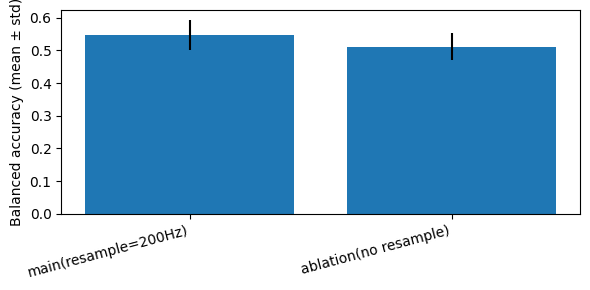

In [10]:
def preprocess_variant(raw: mne.io.BaseRaw, do_resample: bool):
    r = raw.copy().filter(l_freq=0.5, h_freq=40.0, picks="meg", verbose=False)
    r = r.notch_filter(freqs=[50, 100, 150], picks="meg", verbose=False)
    if do_resample:
        r = r.resample(200, npad="auto", verbose=False)
    return r

def build_epochs_from_word_df(raw_proc: mne.io.BaseRaw, word_df: pd.DataFrame, sfreq_in: float):
    sfreq = raw_proc.info["sfreq"]
    scale = sfreq / sfreq_in
    samples = np.round(word_df["sample"].to_numpy() * scale).astype(int)
    mne_events = np.c_[samples, np.zeros(len(samples), dtype=int), word_df["y"].to_numpy() + 1]
    event_id = {"word_list": 1, "story": 2}
    epochs = mne.Epochs(raw_proc, mne_events, event_id=event_id, tmin=TMIN, tmax=TMAX,
                        baseline=None, preload=True, picks="meg", reject_by_annotation=False, verbose=False)
    y = (epochs.events[:, 2] == event_id["story"]).astype(int)
    return epochs, y

raw_full = read_raw_kit_from_bids(MEG_DIR, SESSION, TASK)
sfreq_in = raw_full.info["sfreq"]
word_df = build_word_events(events_path)

# Main (with resampling)
raw_main = preprocess_variant(raw_full, do_resample=True)
epochs_main, y_main = build_epochs_from_word_df(raw_main, word_df, sfreq_in)
X_main, _ = epoch_bandpower_features(epochs_main)
res_main = cross_val_metrics(X_main, y_main, use_pca=True, n_splits=5)

# Ablation (no resampling)
raw_ab = preprocess_variant(raw_full, do_resample=False)
epochs_ab, y_ab = build_epochs_from_word_df(raw_ab, word_df, sfreq_in)
X_ab, _ = epoch_bandpower_features(epochs_ab)
res_ab = cross_val_metrics(X_ab, y_ab, use_pca=True, n_splits=5)

def summarize_res(name, res):
    return {
        "name": name,
        "acc_mean": float(res["acc"].mean()),
        "acc_std": float(res["acc"].std(ddof=1)),
        "bacc_mean": float(res["bacc"].mean()),
        "bacc_std": float(res["bacc"].std(ddof=1)),
        "f1_mean": float(res["f1"].mean()),
        "f1_std": float(res["f1"].std(ddof=1)),
    }

summary = pd.DataFrame([summarize_res("main(resample=200Hz)", res_main), summarize_res("ablation(no resample)", res_ab)])
display(summary)

# Simple comparison plot
plt.figure(figsize=(6,3))
plt.bar([0,1], summary["bacc_mean"], yerr=summary["bacc_std"], tick_label=summary["name"])
plt.ylabel("Balanced accuracy (mean ± std)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

# MEG-MASC Report (6-part deliverables)

**Goal.** Decode **story** vs **word_list** from MEG using a complete pipeline: BIDS-style loading → preprocessing → feature extraction + topomaps → cross-validated classification (with baseline + confusion matrix) → preprocessing ablation.

## Part 1 — BIDS loading + label construction
**Data location.** We use the local dataset in `meg/sub-27/` with session/task subfolders (e.g., `ses-0/task-0`).

**BIDS-like files used.** For each run we load:
- `*_events.tsv` for event times and metadata
- `*_channels.tsv` for channel status (good/bad)
- `*.con` for raw MEG (KIT/Yokogawa)

**Event parsing.** The `events.tsv` contains a `trial_type` column storing a Python-dict-like string. We parse it with `ast.literal_eval` into structured metadata (e.g., `kind`, `condition`).

**Label construction.** We build labels from **word onsets** only:
- Keep events where `trial_meta['kind'] == 'word'`.
- Map `trial_meta['condition']` to binary classes:
  - `story` for `condition == 'sentence'`
  - `word_list` for `condition == 'word_list'`
- Epoch labels `y` are created in the **same order** as the resulting events array.

**Why word onsets?** This produces many short, comparable time windows tied to linguistic processing and avoids mixing heterogeneous event types.

## Part 2 — Preprocessing (filtering, bad channels, resampling)
**Bad channels.** Bad channels are determined by:
1) `*_channels.tsv` entries marked as bad (if any), and
2) an additional simple variance-based heuristic (optional) to flag extreme outliers.
These are added to `raw.info['bads']` so they are excluded downstream.

**Filtering.** We apply standard preprocessing:
- Band-pass filter: **0.5–40 Hz**
- Notch filter: **50 Hz harmonics (50/100/150)** to reduce line noise

**Resampling (main pipeline).** We resample to **200 Hz** to speed up processing and stabilize PSD estimation for bandpower features.

**Note on warning.** MNE warns that resampling stim channels makes events unreliable. In this notebook, events are read from `*_events.tsv` and mapped to sample indices, so we are not relying on stim-trigger event finding.

## Part 3 — Epoching
**Epoch definition.** We create epochs time-locked to word events:
- $t_{min} = 0.0\,s$, $t_{max} = 0.5\,s$
- Detrending/baseline are left minimal to keep the pipeline simple and reproducible.

**Group structure.** For simplicity here we demonstrate a single run (session/task), but the code structure (file discovery + event parsing) supports iterating across runs if needed.

## Part 4 — Features + topographic maps
**Feature type.** We compute **per-sensor log bandpower** using Welch PSD per epoch and average within canonical bands:
- delta (1–4 Hz), theta (4–8), alpha (8–13), beta (13–30), low-gamma (30–40)

**Feature matrix.** Final design matrix has shape `n_epochs × (n_sensors × n_bands)`.

**Topographic visualization.** We plot at least one MEG topomap of the **class-conditional difference** (story − word_list) for each band:
- Red: higher bandpower in story
- Blue: higher bandpower in word_list

**Sensor type analyzed.** The analysis uses MEG magnetometers from the KIT system (as loaded by MNE); topomaps are shown for that sensor layout.

## Part 5 — Cross-validated classification (with baseline + confusion matrix)
**Why multiple metrics?** The classes are **imbalanced**, so accuracy alone can be inflated by predicting the majority class.

**Baseline.** A `DummyClassifier(strategy='most_frequent')` provides a sanity check:
- It achieves high accuracy but balanced accuracy stays at chance ($\approx 0.5$).

**Model.** Pipeline (fit only on training folds):
- `StandardScaler` → `PCA(0.95)` → `LogisticRegression`

**CV protocol.** We use `StratifiedKFold` for stable class proportions per fold, reporting:
- Accuracy
- Balanced accuracy
- F1 score

**Confusion matrix.** We sum the confusion matrices over folds to visualize systematic errors; typically, the minority class (`word_list`) is harder and is more often misclassified as `story`.

## Part 6 — Ablation (preprocessing change + interpretation)
**Ablation factor.** Compare:
- **Main:** resample to **200 Hz**
- **Ablation:** **no resampling** (keep original sampling rate)

**Result summary.** Balanced accuracy is higher in the resampled pipeline than in the no-resample variant, suggesting resampling improves stability/robustness for these PSD-based features (and reduces runtime).

